In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
labels = pd.read_csv("class.tsv", sep="\t", header=None)
labels.columns = ["class"]

expr = pd.read_csv("filtered.tsv", sep="\t", index_col=0)

gene_map = pd.read_csv("columns.tsv", sep="\t", comment="#")
gene_map = gene_map[["ID", "GeneSymbol"]]
gene_map.columns = ["gene_id", "gene_name"]

print("Labels shape:", labels.shape)
print("Expression shape:", expr.shape)
print("Gene map shape:", gene_map.shape)
print(gene_map.head())

Labels shape: (105, 1)
Expression shape: (105, 16173)
Gene map shape: (27648, 2)
   gene_id gene_name
0        1      ACTB
1        2      ACTB
2        3       NaN
3        4       NaN
4        5       NaN


In [3]:
expr.columns = expr.columns.astype(str)

xbp1_id = gene_map[gene_map["gene_name"] == "XBP1"]["gene_id"].values[0]
gata3_id = gene_map[gene_map["gene_name"] == "GATA3"]["gene_id"].values[0]

xbp1_col = str(xbp1_id).rjust(len(expr.columns[0]))
gata3_col = str(gata3_id).rjust(len(expr.columns[0]))

xbp1_values = expr[xbp1_col].values
gata3_values = expr[gata3_col].values

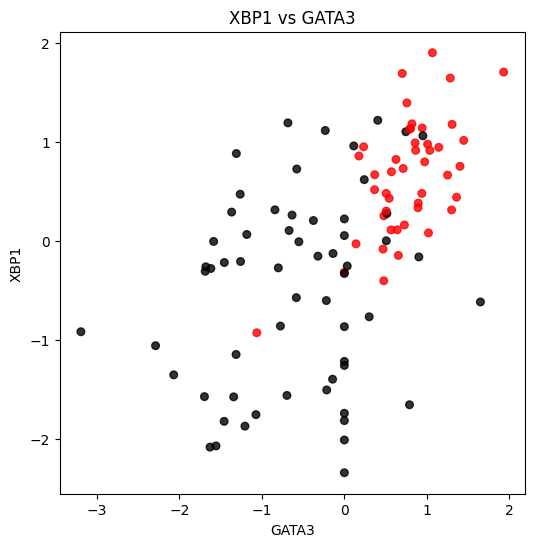

In [4]:
xbp1_values = (xbp1_values - np.mean(xbp1_values)) / np.std(xbp1_values)
gata3_values = (gata3_values - np.mean(gata3_values)) / np.std(gata3_values)

colors = ["red" if c == 1 else "black" for c in labels["class"]]

plt.figure(figsize=(6,6))
plt.scatter(gata3_values, xbp1_values, c=colors, s=30, alpha=0.8)

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("XBP1 vs GATA3")

plt.show()

In [5]:
X = np.column_stack((gata3_values, xbp1_values))  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pc1 = X_pca[:, 0]

print(pc1.min(), pc1.max())

-2.9042135733458876 2.57155734515104


In [6]:
print(expr.shape)
print(expr.iloc[:5, :5])

(105, 16173)
              2       6      12      13      15
    1                                          
 0.0534  0.2558 -1.1449 -0.3843  0.4021  0.3512
 0.4866  0.4736 -0.1135  0.1500  0.6200 -0.0146
 0.5908  0.6439 -0.7664 -0.5907 -1.0596  1.2956
-0.4971 -0.4926 -0.8767 -0.3029 -0.4014  0.7181
 0.2970  0.2770 -0.6193 -0.3508  0.0383 -0.2477


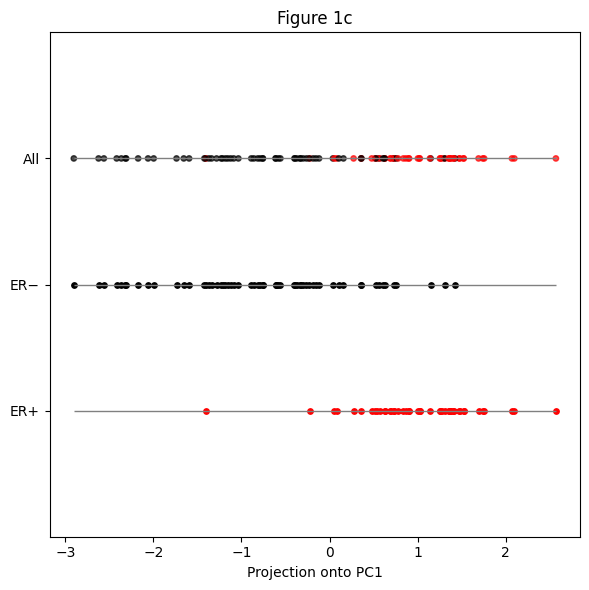

In [8]:
label_vals = labels["class"].values

pc1_er_pos = pc1[label_vals == 1]
pc1_er_neg = pc1[label_vals == 0]

colors = ["red" if i == 1 else "black" for i in label_vals]

y_all = np.ones_like(pc1) * 0.2        # top
y_neg = np.zeros_like(pc1_er_neg)      # middle
y_pos = np.ones_like(pc1_er_pos) * -0.2  # bottom

plt.figure(figsize=(6,6))

xmin, xmax = pc1.min(), pc1.max()
plt.hlines([0.2, 0, -0.2], xmin, xmax, colors='gray', linewidth=1)

plt.scatter(pc1, y_all, c=colors, s=15, alpha=0.7)
plt.scatter(pc1_er_neg, y_neg, color='black', s=15)
plt.scatter(pc1_er_pos, y_pos, color='red', s=15)

plt.yticks([0.2, 0, -0.2], ["All", "ER−", "ER+"])
plt.ylim(-0.4, 0.4)

plt.xlabel("Projection onto PC1")
plt.title("Figure 1c")

plt.tight_layout()
plt.show()